In [207]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff
MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4

In [208]:
# def adu_to_kev(adu, gain, offset):
#     global C1, C2, C3, C4
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu(kev, gain, offset):
#     global C1, C2, C3, C4

#     return ((kev - C4) * (C1 * gain) + C2 * gain + C3 * offset)

In [209]:


def adu_to_kev(adu, gain, offset):
    return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

def kev_to_adu( kev, gain, offset):
    return (kev - C4) * (C1 * gain) + C2 * gain + C3 * offset

In [210]:
gain = 1
offset = 0.0

In [211]:
def wrap_offset_to_hardware(offset: float) -> float:
        """Wraps unwrapped software offset into FPGA register bounds [-1.0, 1.0]."""
        while offset > 1.0:
            offset -= 1.0
        while offset < -1.0:
            offset += 1.0
        return offset
def set_energy_range(
        kev_start: float,
        kev_end: float,
        adu_start: int = 0,
        adu_end: int = 1023,
        buffer: int = 0,
    ):
        # global C1, C2, C3, C4
        C1 = 99.90741625
        C2 = 1225.60912165
        C3 = 1024.0
        C4 = 14.4
        # Always lock hardware baseline to 0 keV so hardware ADU is never negative
        hw_kev_start = 0.0
        
        eff_adu_start = adu_start + buffer
        eff_adu_end = adu_end - buffer
        
        delta_adu = eff_adu_end - eff_adu_start
        delta_kev = kev_end - kev_start

        raw_gain = delta_adu / (C1 * delta_kev)
        if raw_gain > 1.0:
            raw_gain = 1.0

        # Calculate hardware offset keeping 0 keV at channel 0
        raw_offset = (
            eff_adu_start - raw_gain * ((hw_kev_start - C4) * C1 + C2)
        ) / C3
        hw_offset = wrap_offset_to_hardware(raw_offset)

        gain = raw_gain
        raw_offset = raw_offset

        # Calculate Python array slices for the requested [kev_start, kev_end] window
        min_adu_needed = max(0, int(np.floor(kev_to_adu(kev_start, raw_gain, raw_offset))))
        max_adu_needed = min(1024, int(np.ceil(kev_to_adu(kev_end, raw_gain, raw_offset))))

        # Update registers
        dev.set_register("histogram", "gain", gain)
        dev.set_register("histogram", "offset", hw_offset)

        return gain, hw_offset, max_adu_needed

In [212]:
# gain, offset, max_index = set_energy_range(6.0, 6.8)
# print(f"Gain: {gain}, Offset: {offset}, Max Index: {max_index}")

In [214]:


RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
dev.base.load_bitfile()

# Signal chain
dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)
dev.set_register('fir9', 'h0', 0.99)




# Peak detector
dev.set_register("peak_detector", "trig_level", 2, raw=True)
# dev.set_register("peak_detector", "fall_level", 1, raw=True)
# dev.set_register("peak_detector", "base_return", 0, raw=True)
# dev.set_register("peak_detector", "dead_time", 1000, raw=True)

# Use 0 for positive-going pulses, 1 for negative-going pulses
dev.set_register("peak_detector", "invert_input", 0, raw=True)

gain, offset, max_index = set_energy_range(14, 14.8)

dev.set_register("peak_detector", "n_integration", 1000)

# Histogram
dev.set_register("histogram", "offset", offset)
dev.set_register("histogram", "gain", gain)

dev.set_register("histogram", "pulse_width", 1024)
dev.set_register("histogram", "clear_bins", 1)
time.sleep(0.01)
dev.set_register("histogram", "clear_bins", 0)
dev.set_register("histogram", "counting_enable", 1)
dev.set_register("histogram", "band_low", 0.0)
dev.set_register("histogram", "band_high", 4)

log = EventLogger(dev)
log.configure(
    band_low=0.0,
    band_high=4,
    flush_ms=100,
)
# log.configure(flush_ms=100)
log.run(duration=5, output_dir="run1")

raw = load_run("run1/events_*.bin")
ts_us, energy, chb = unpack(raw)

print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")

print(
    dev.get_register("event_logger", "band_low", raw=True),
    dev.get_register("event_logger", "band_high", raw=True),
)
a, b, ppm = fit_clock("run1/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)


TimeoutError: [Errno 60] Operation timed out

In [ ]:
dev.get_all_registers("histogram")
# offset

{'offset': 0.2080078125,
 'gain': 1.0,
 'band_low': 0.0,
 'band_high': 0.0,
 'clear_bins': 0.0,
 'counting_enable': 1.0,
 'reset': 0.0,
 'read_address': 0.0,
 'pulse_width': 1024.0,
 'read_data': 10.0,
 'data_ready': 1.0,
 'overflow_flag': 0.0}

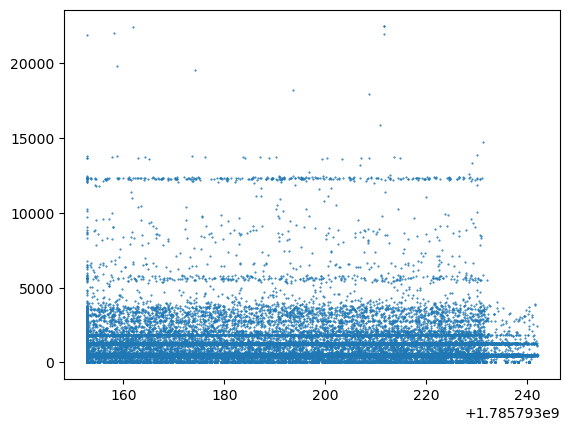

In [ ]:
plt.plot(t_unix, energy, '.', markersize=1)

78638
78638
[ 434  465 1248 ...  452  474  467]


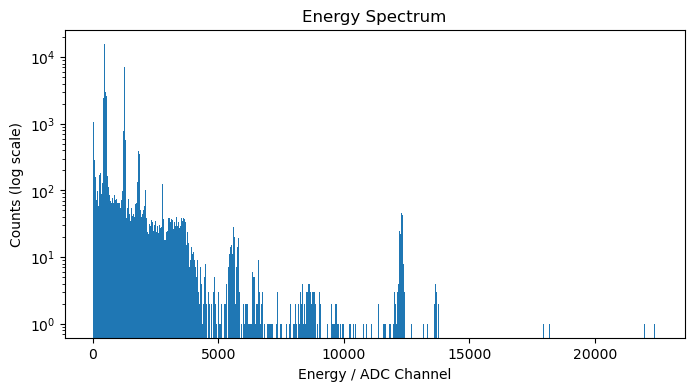

In [ ]:

energy_kev = [adu_to_kev(i, gain=gain, offset=offset) for i in range(len(energy))]
print(len(energy_kev))
print(len(energy))

print(energy)


# # 1. Correct Plot for Raw Event Sequence
# plt.figure(figsize=(8, 4))
# plt.plot(energy, linewidth=0.5)
# plt.title("Pulse Height per Event")
# plt.xlabel("Event Index")
# plt.ylabel("Energy / ADC Channel")
# plt.show()

# 2. Correct Plot for True Energy Spectrum
plt.figure(figsize=(8, 4))
plt.hist(energy, bins=1024, log=True)
plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare, poisson

# -------------------------------------------------------------
# Step 1: Clock Alignment & Timestamps
# -------------------------------------------------------------
a, b, ppm = fit_clock("run1/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)
print(t_unix)
print(len(energy))


energy_kev = np.array(adu_to_kev(energy, gain=gain, offset=offset))

# ROI centered around 14.4 keV
roi_min, roi_max = 14.0, 14.8
peak_mask = (energy_kev >= roi_min) & (energy_kev <= roi_max)
print(peak_mask)


Crystal drift: +18718745.0 ppm
[1.78579315e+09 1.78579315e+09 1.78579315e+09 ... 1.78579324e+09
 1.78579324e+09 1.78579324e+09]
78638
[False False False ... False False False]


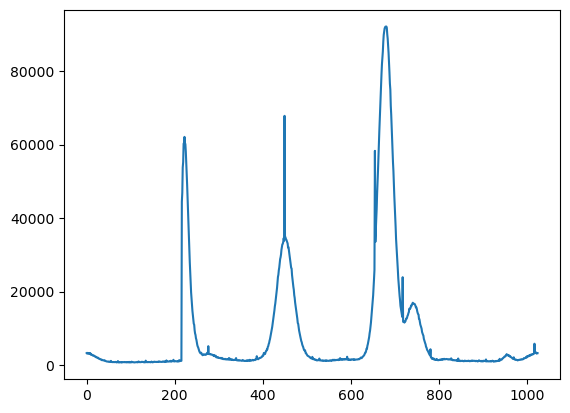

In [ ]:
histogram = dev.read_sequential_axi_data("histogram", "read_address", "read_data", 0, 1023)
plt.plot(histogram)

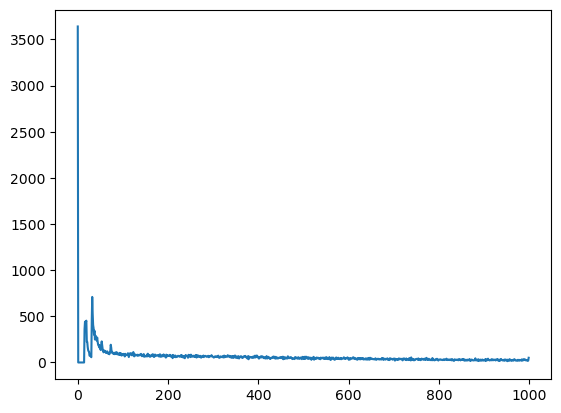

In [ ]:
h,b = np.histogram(ts_us[1:]-ts_us[:-1], np.linspace(0, 1e3, 1000))
plt.plot(b[:-1], h)

(-1.0, 200.0)

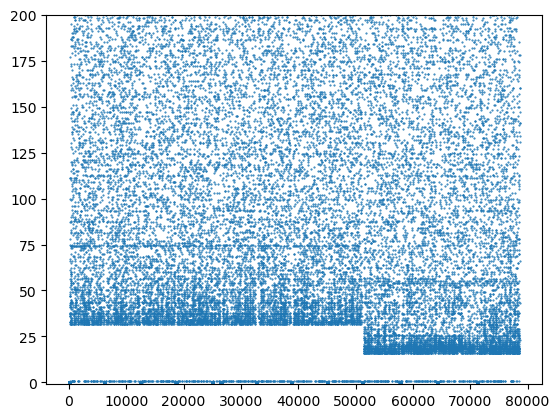

In [ ]:
plt.plot(ts_us[1:]-ts_us[:-1], '.', markersize=1)
plt.ylim(-1, 200)